how can we support fast “give me 20 similar songs” queries when feature vectors are high-dimensional?

11/11-2025

Cluster the songs based on the feature vectors:<br> 
Try algorithms like **k-means** or **DBSCAN** in the combined feature space. <br>
Optionally, build a **k-nearest-neighbour graph** from similarity scores and run a graph clustering method (e.g. **community detection**) to find “music communities”.

### **Cluster the LSH data:** 

Note: The previous step (**Step 2**), did Locality Sensitive Hashing (LSH) on the feature vectors to generate approximate nearest neighbours.
<br>
LSH maps similar songs into the same or nearby hash buckets with high probability. These buckets allow us to quickly retrieve candidate sets of similar songs without computing all pairwise distances, between every single vector.
<br>
During clustering, this pre-processing step can significantly reduce computation time, since comparisons can be limited to items within the same or similar buckets instead of the entire dataset.
<br>
<br>
Thus, LSH acts as a pre-treatment that enables scalable similarity search and accelerates the downstream clustering, performed in this notebook. 

### **Loading subset data and generating placeholder LSH data:**

In [32]:
root_path = "../" #All the data is outside this folder. 

Note: If we just read the e.g. first 200 lines, we will only get the track_genre = acoustic entries.
Therefore, when making the subset, we need to mix the entries that we read. 

In [60]:
import pandas as pd
import numpy as np

# -----------------------------
# 1. Load subset of CSV
# -----------------------------
# Load only first 200 rows (change nrows as needed)
#df = pd.read_csv(root_path+"dataset_with_lastfm_all.csv", nrows=200)

# Read whole CSV: 
df = pd.read_csv(root_path+"dataset_with_lastfm_all.csv")

# Drop 'Unnamed: 0' if present
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Take a random sample of 200 rows - overwrite the df, which covers the entire dataset. 
df = df.sample(n=200, random_state=42)

print("Checking how many different track genres are in the subset:")
display( pd.DataFrame(df['track_genre'].value_counts()) )


# Drop 'Unnamed: 0' if it exists
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print("Data loaded:", df.shape)
display(df.head())

# Drop non-numeric columns if any (e.g., 'track_id','artists', etc.)
numeric_df = df.select_dtypes(include=[np.number])
print("Numeric columns used:", numeric_df.columns.tolist())


Checking how many different track genres are in the subset:


,count
track_genre,
heavy-metal,7
drum-and-bass,7
industrial,6
study,6
electronic,5
...,...
synth-pop,1
pagode,1
indian,1


Data loaded: (200, 25)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,liveness,valence,tempo,time_signature,track_genre,track_search,lfm_playcount,lfm_listeners,lfm_duration_ms,lfm_tags
37609,2gpz5SQb1NEPPxjbSglAZK,Pappo,Buscando un Amor,Trabajo Forzado,23,248066,NaN,0.547,0.699,9,...,0.1310,0.622,75.814,4,heavy-metal,Trabajo Forzado - Pappo,4373.0,1433.0,248000.0,blues;rock;rock argentino;argentina;blues rock...
35970,3oYj1UaQtkX0R9iuaV2jMj,Eterna Inocencia,No bien abran las flores,Hojas Amarillas,31,255905,NaN,0.576,0.709,2,...,0.1250,0.579,140.003,4,hardcore,Hojas Amarillas - Eterna Inocencia,2195.0,428.0,255000.0,melodic hardcore;hardcore melodico;hardcore pu...
61541,2WkjVlKU47qVKyPUehA5eH,SONNY NITEZ,MORNING 2007,MORNING 2007,52,118763,NaN,0.752,0.485,5,...,0.3420,0.819,95.003,4,sad,MORNING 2007 - SONNY NITEZ,69823.0,11268.0,118000.0,NaN
652,4XBcShO4h4X55x9yMmyKHL,Allman Brown,1000 Years,Sweetest Thing,54,218502,NaN,0.546,0.411,2,...,0.0955,0.528,79.785,4,acoustic,Sweetest Thing - Allman Brown,326871.0,75287.0,218000.0,singer-songwriter;folk rock;indie;rock;england...
37281,7pvMOx4cYIamyNeYLVhTWS,Tren Loco,Venas De Acero,Venas De Acero,25,362520,NaN,0.534,0.949,4,...,0.5370,0.334,114.988,4,heavy-metal,Venas De Acero - Tren Loco,3454.0,858.0,408000.0,heavy metal;speed metal;argentina;heavy argent...


Numeric columns used: ['popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'lfm_playcount', 'lfm_listeners', 'lfm_duration_ms']


In [61]:
#Different type of track genres in the list: 
print(df["track_genre"].unique()) 

['heavy-metal' 'hardcore' 'sad' 'acoustic' 'blues' 'forro' 'iranian'
 'country' 'j-idol' 'emo' 'mandopop' 'r-n-b' 'industrial' 'bluegrass'
 'alt-rock' 'party' 'show-tunes' 'ambient' 'dub' 'latino' 'french'
 'sertanejo' 'trance' 'swedish' 'rockabilly' 'disney' 'tango'
 'chicago-house' 'sleep' 'salsa' 'trip-hop' 'k-pop' 'death-metal'
 'drum-and-bass' 'power-pop' 'cantopop' 'electronic' 'club' 'brazil'
 'happy' 'romance' 'dancehall' 'black-metal' 'spanish' 'malay' 'study'
 'j-dance' 'minimal-techno' 'kids' 'progressive-house' 'hip-hop' 'ska'
 'gospel' 'rock-n-roll' 'funk' 'anime' 'comedy' 'grindcore' 'classical'
 'german' 'singer-songwriter' 'new-age' 'guitar' 'idm' 'edm' 'pop'
 'electro' 'grunge' 'opera' 'mpb' 'breakbeat' 'afrobeat' 'latin'
 'metalcore' 'goth' 'groove' 'garage' 'piano' 'children' 'turkish'
 'deep-house' 'pop-film' 'synth-pop' 'pagode' 'indian' 'dubstep'
 'alternative']


In [66]:
# -----------------------------
# 2. Generate approximate LSH-like vectors
# -----------------------------
# Simulate LSH signatures by random projection
# (this approximates hashing similar vectors together)
def generate_lsh_vectors(data, n_bits=32, seed=42):
    rng = np.random.RandomState(seed)
    random_planes = rng.randn(data.shape[1], n_bits)
    projections = np.dot(data, random_planes)
    lsh_vectors = (projections > 0).astype(int)
    return lsh_vectors


#generate_lsh_vectors() uses random hyperplane projection (a standard way to approximate LSH).
#You can control the number of bits (hash length) with n_bits.

lsh_vectors = generate_lsh_vectors(numeric_df, n_bits=64)

lsh_vectors = lsh_vectors + np.random.normal(0, 0.01, lsh_vectors.shape) #Important: Adding noise. 
#Without this, the place-holder clusters will be too similar, and we will only get 1 cluster.

print("LSH-like vectors shape:", lsh_vectors.shape)

LSH-like vectors shape: (200, 64)


### **K-means:**

Centroid, Partition-based. <br>
Requires a user-defined K-value. <br>
Might be hard to scale up. 

In [34]:
#pip install scikit-learn


Cluster assignments:


,count
cluster,
2,45
4,44
1,43
0,38
3,30


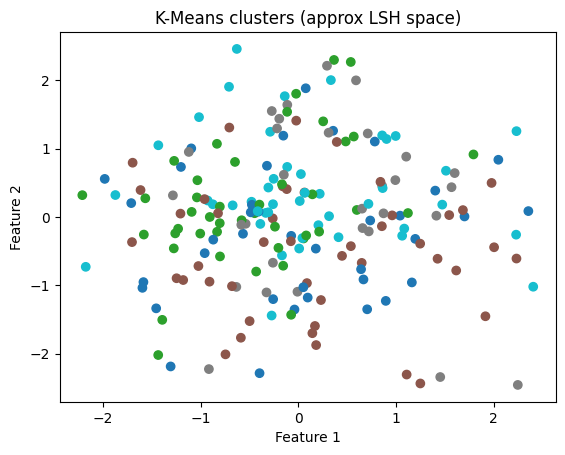

In [68]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


n_clusters = 5 #For now we put the k-value as 5. 
#But we can later e.g. try to put it near the amount of different genres, or something corresponding.


# -----------------------------
# Run K-Means clustering
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(lsh_vectors)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print("\nCluster assignments:")
display( pd.DataFrame(df['cluster'].value_counts()) )

# -----------------------------
# Visualize
# -----------------------------
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=df['cluster'], cmap='tab10')
plt.title("K-Means clusters (approx LSH space)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


In [ ]:
#We can compare how well clusters align with the track genre:
pd.crosstab(df['track_genre'], df['cluster']) 

cluster,0,1,2,3,4
track_genre,,,,,
acoustic,1,0,0,0,0
afrobeat,0,0,0,0,1
alt-rock,0,0,2,1,0
alternative,0,1,0,0,0
ambient,2,1,1,0,0
...,...,...,...,...,...
synth-pop,0,0,0,0,1
tango,0,0,0,0,1
trance,1,0,1,0,1


### **CURE (Clustering Using REpresentatives) algorithm:**

Hierarchical clustering. Uses representative points instead of centroids. <br>
Might be more suitable for large datasets. 

### **DBSCAN (Density-Based Spatial Clustering of Applications with Noise):**

Density-based. Densly packed. <br>
Note: Usually works well on PCA or UMAP dimensionality-reduced data, but can struggle with high dimensionality. 

### **Graph-Based Clustering:**

- Nodes = songs
- Edges = similarity between songs (weighted)

Community detection to identify “music communities”

**Louvain algorithm**

Two-phase. Each note starts as a community. No user-defined K-value. Works decent on large data/ is scalable. 

**Spectral clustering**

Uses eigenvectors and K-means. Can be used on k-nearest neighbors graph (k-NN graph) from LSH. 

**Girvan-Newman Algorithm**

Can find communities. Might be tricky on large graphs, although limiting edges based on the LSH buckets, might help. 